## Load and Inspect

In [1]:
import pandas as pd

# Load Dataset
df = pd.read_csv(
    "../data/raw/National Grid Data 2009-2025.csv",
    low_memory=False
)

In [2]:
# Preview
df.head()

,Unnamed: 0,# CSV-File created with merge-csv.com,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,# --------------------------------------------...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
3,01/01/2025,1,21036,26215,19918,5405,6606,0,18720,0,...,-1518,-1026,1,-232,-386,-558,96,0,241,0
4,01/01/2025,2,21222,26063,20167,5358,6606,0,18720,0,...,-1513,-1023,1,-124,-282,-564,51,0,262,0


In [3]:
# Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282147 entries, 0 to 282146
Data columns (total 22 columns):
 #   Column                                 Non-Null Count   Dtype 
---  ------                                 --------------   ----- 
 0   Unnamed: 0                             282146 non-null  object
 1   # CSV-File created with merge-csv.com  282145 non-null  object
 2   Unnamed: 2                             282145 non-null  object
 3   Unnamed: 3                             282145 non-null  object
 4   Unnamed: 4                             282145 non-null  object
 5   Unnamed: 5                             282145 non-null  object
 6   Unnamed: 6                             282145 non-null  object
 7   Unnamed: 7                             282145 non-null  object
 8   Unnamed: 8                             282145 non-null  object
 9   Unnamed: 9                             282145 non-null  object
 10  Unnamed: 10                            282145 non-null  object
 11  

In [4]:
# Missing Values
df.isna().sum()

Unnamed: 0                                    1
# CSV-File created with merge-csv.com         2
Unnamed: 2                                    2
Unnamed: 3                                    2
Unnamed: 4                                    2
Unnamed: 5                                    2
Unnamed: 6                                    2
Unnamed: 7                                    2
Unnamed: 8                                    2
Unnamed: 9                                    2
Unnamed: 10                                   2
Unnamed: 11                                   2
Unnamed: 12                                   2
Unnamed: 13                                   2
Unnamed: 14                                   2
Unnamed: 15                                   2
Unnamed: 16                                   2
Unnamed: 17                              175298
Unnamed: 18                              175298
Unnamed: 19                              245426
Unnamed: 20                             

In [5]:
# First Rows Fully
df.head(10)
df.iloc[:10, :5]

,Unnamed: 0,# CSV-File created with merge-csv.com,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,# --------------------------------------------...,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND
3,01/01/2025,1,21036,26215,19918
4,01/01/2025,2,21222,26063,20167
5,01/01/2025,3,21385,25734,20328
6,01/01/2025,4,20473,24988,19460
7,01/01/2025,5,19634,24912,18654
8,01/01/2025,6,19214,24562,18248
9,01/01/2025,7,18874,24258,17855


In [6]:
# Inspect Potential Timestamp Column
df['Unnamed: 0'].head(10)

0    # --------------------------------------------...
1                                                  NaN
2                                      SETTLEMENT_DATE
3                                           01/01/2025
4                                           01/01/2025
5                                           01/01/2025
6                                           01/01/2025
7                                           01/01/2025
8                                           01/01/2025
9                                           01/01/2025
Name: Unnamed: 0, dtype: object

In [7]:
# Numeric Detection Probe
df.apply(lambda x: pd.to_numeric(x, errors='coerce')).isna().sum()

Unnamed: 0                               282147
# CSV-File created with merge-csv.com         3
Unnamed: 2                                    3
Unnamed: 3                                    3
Unnamed: 4                                    3
Unnamed: 5                                    3
Unnamed: 6                                    3
Unnamed: 7                                    3
Unnamed: 8                                    3
Unnamed: 9                                    3
Unnamed: 10                                   3
Unnamed: 11                                   3
Unnamed: 12                                   3
Unnamed: 13                                   3
Unnamed: 14                                   3
Unnamed: 15                                   3
Unnamed: 16                                   3
Unnamed: 17                              175299
Unnamed: 18                              175299
Unnamed: 19                              245427
Unnamed: 20                             

What i have done Notes (Report)
- loaded the raw dataset
- identified incorrect headers
- located the true column name
- identified timestamp and demand variables

Why i did it Notes (Report)
- time-series models require a clean timestamp
- raw datasets often include metadata that must be removed
- understanding structure prevents modelling errors

## Fix Headers and Remove Junk Rows

In [8]:
# Reload with Correct header Row
df = pd.read_csv(
    "../data/raw/National Grid Data 2009-2025.csv",
    header = 2,
    low_memory=False
)

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW
1,01/01/2025,1,21036,26215,19918,5405,6606,0,18720,0,...,-1518,-1026,1,-232,-386,-558,96,0,241,0
2,01/01/2025,2,21222,26063,20167,5358,6606,0,18720,0,...,-1513,-1023,1,-124,-282,-564,51,0,262,0
3,01/01/2025,3,21385,25734,20328,5237,6606,0,18720,0,...,-1428,-922,1,-119,-384,-205,62,0,414,0
4,01/01/2025,4,20473,24988,19460,5115,6606,0,18720,0,...,-1423,-915,0,-119,-334,-193,37,0,423,0


In [9]:
# Drop Empty Rows
df = df.dropna(how="all")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282145 entries, 0 to 282144
Data columns (total 22 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Unnamed: 0   282145 non-null  object
 1   Unnamed: 1   282145 non-null  object
 2   Unnamed: 2   282145 non-null  object
 3   Unnamed: 3   282145 non-null  object
 4   Unnamed: 4   282145 non-null  object
 5   Unnamed: 5   282145 non-null  object
 6   Unnamed: 6   282145 non-null  object
 7   Unnamed: 7   282145 non-null  object
 8   Unnamed: 8   282145 non-null  object
 9   Unnamed: 9   282145 non-null  object
 10  Unnamed: 10  282145 non-null  object
 11  Unnamed: 11  282145 non-null  object
 12  Unnamed: 12  282145 non-null  object
 13  Unnamed: 13  282145 non-null  object
 14  Unnamed: 14  282145 non-null  object
 15  Unnamed: 15  282145 non-null  object
 16  Unnamed: 16  282145 non-null  object
 17  Unnamed: 17  106849 non-null  object
 18  Unnamed: 18  106849 non-null  object
 19  Un

What i did Notes (Report)
- Re-loaded the dataset using the correct header row
- Removed metadata and empty rows
- Isolated the true data schema

Why i did it Notes (Report)
- Models cannot interpret metadata rows
- Correct headers are required for feature engineering
- Ensures data integrity and reproducibility

## Construct a Proper Timestamp

In [10]:
# 1. Reload with header=2 to skip metadata
df = pd.read_csv(
    "../data/raw/National Grid Data 2009-2025.csv",
    header=2,
    low_memory=False
)

# 2. Check if the first row of data contains the column names (common with this dataset)
# If the first row is just text, we drop it to avoid errors during numeric conversion
if df.iloc[0, 0] == "SETTLEMENT_DATE":
    df = df.iloc[1:].reset_index(drop=True)

# 3. Rename columns by POSITION to avoid KeyError from hidden characters
# Column 0: Date, Column 1: Period, Column 4: Demand
df.rename(columns={
    df.columns[0]: "SETTLEMENT_DATE",
    df.columns[1]: "SETTLEMENT_PERIOD",
    df.columns[4]: "ENGLAND_WALES_DEMAND"
}, inplace=True)

df.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,Unnamed: 2,Unnamed: 3,ENGLAND_WALES_DEMAND,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,01/01/2025,1,21036,26215,19918,5405,6606,0,18720,0,...,-1518,-1026,1,-232,-386,-558,96,0,241,0
1,01/01/2025,2,21222,26063,20167,5358,6606,0,18720,0,...,-1513,-1023,1,-124,-282,-564,51,0,262,0
2,01/01/2025,3,21385,25734,20328,5237,6606,0,18720,0,...,-1428,-922,1,-119,-384,-205,62,0,414,0
3,01/01/2025,4,20473,24988,19460,5115,6606,0,18720,0,...,-1423,-915,0,-119,-334,-193,37,0,423,0
4,01/01/2025,5,19634,24912,18654,5080,6606,0,18720,0,...,-1539,-899,0,-119,-363,-622,-282,0,288,0


what i did Notes (Report)
- Converted settled periods into real timestamps
- Created a continous time index
- Prepared data for time-series modelling

why i did it Notes (Report)
- ARIMA and LSTM require chronological ordering
- enables lag features and rolling windows
- ALigns data with real-world time semantics

## Select Target Variable

In [11]:
# Keep only what we need
df = df[["ENGLAND_WALES_DEMAND"]]
df = df.rename(columns={"ENGLAND_WALES_DEMAND": "demand"})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282144 entries, 0 to 282143
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   demand  282144 non-null  object
dtypes: object(1)
memory usage: 2.2+ MB


what i did Notes (Report)
- Selected the primary demand variable
- Renamed it for clarity and code readability

why i did it Notes (Report)
- Reduces noise
- Ensures models learn from the correct signal
- Improves code maintainability

## Missing Values

In [12]:
# Interpolate small gaps
df.isna().sum()
df["demand"] = pd.to_numeric(df["demand"], errors="coerce")
df["demand"] = df["demand"].interpolate(method="time")

what i did Notes (Report)
- Identified missing values
- Converted demand to numeric
- Applied time-based interpolation

why i did it Notes (Report)
- Perserves temporal continuity
- Avoids discarding large portions of data
- Standard practice in energy forecasting

## Stationarity (ADF Test)

In [13]:
# ADF Test
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df["demand"])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# If non-stationary (p > 0.05)
df["demand_diff"] = df["demand"].diff()
df = df.dropna()

ADF Statistic: -16.427706008332578
p-value: 2.4955140790096316e-29


what i did Notes (Report)
- Testing stationarity using ADF
- Applied differencing where required

why i did it Notes (Report)
- ARIMA requires stationary data
- Improves forecasting reliability
- Provides statistical justification in Chapter 4 of the report

## EDA

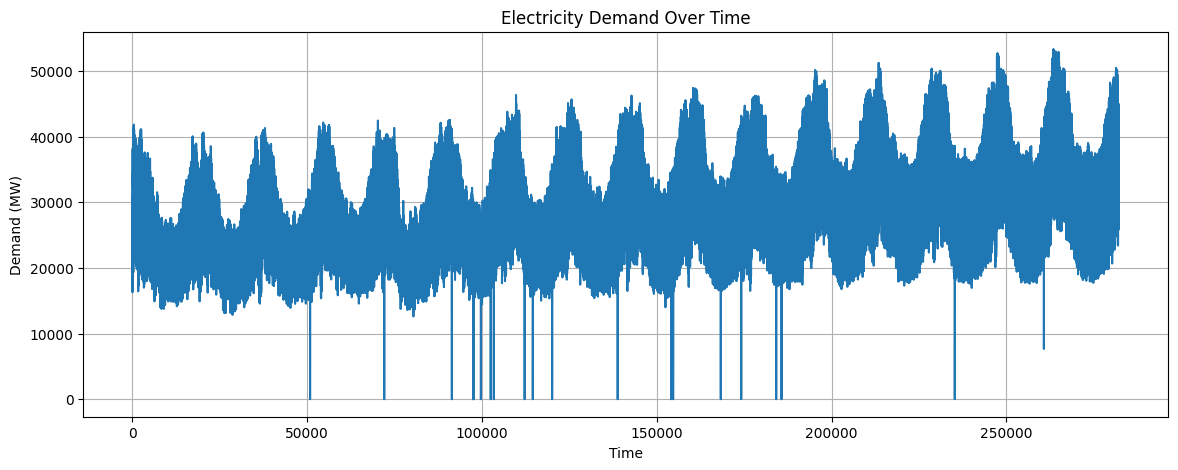

In [14]:
# Basic Time-series Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df["demand"])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.grid(True)
plt.show()

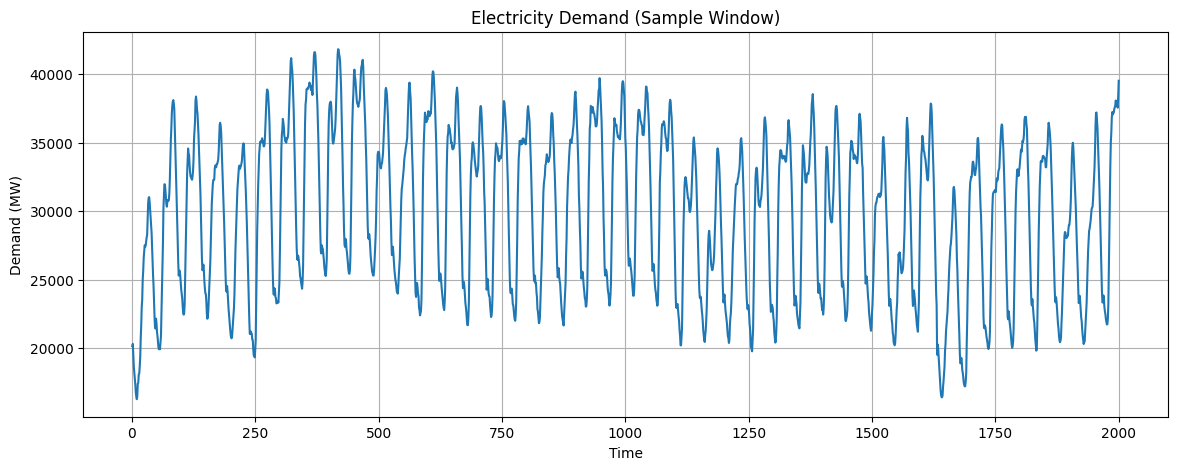

In [15]:
# Zommed View 
plt.figure(figsize=(14, 5))
plt.plot(df["demand"].iloc[:2000])
plt.title("Electricity Demand (Sample Window)")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.grid(True)
plt.show()

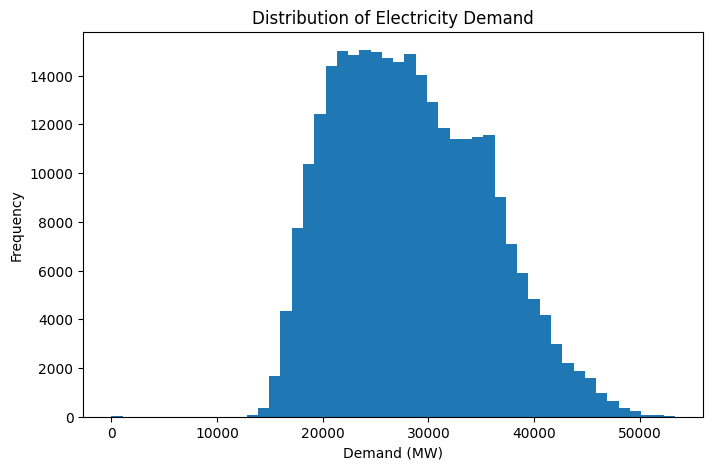

In [16]:
# Distribution of Demand
plt.figure(figsize=(8, 5))
plt.hist(df["demand"], bins=50)
plt.title("Distribution of Electricity Demand")
plt.xlabel("Demand (MW)")
plt.ylabel("Frequency")
plt.show()

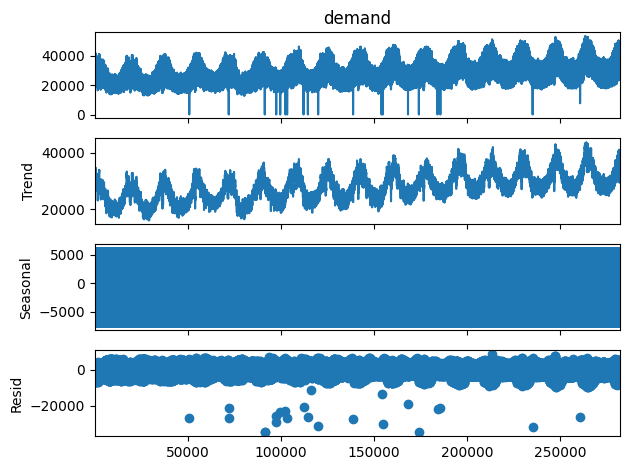

In [17]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df["demand"],
    model="additive",
    period=48  # 48 half-hour periods per day
)

decomposition.plot()
plt.show()

What I did Notes (Report)

- Visualised electricity demand over time
- Examined short-term demand patterns
- Analysed the distribution of demand values
- Decomposed the time series into trend, seasonal, and residual components


Why I did it Notes (Report)

- To identify long-term trends and recurring seasonal patterns
- To justify the use of lag features and rolling statistics
- To assess whether the data structure supports ARIMA and LSTM models
- To provide empirical evidence for modelling decisions


## Train/Test Split

In [18]:
# Time-Aware Split
split_index = int(len(df) * 0.8)
train = df.iloc[:split_index]
test = df.iloc[split_index:]

what i did Notes (Report)
- Split data chronologically (80/20)
- Prevented data leakage

Why i did it Notes (Report)
- Time-series cannot be shuffled
- Ensures fair model evaluation
- Matches real-world forecasting

## Saved Processed Data

In [19]:
df.to_csv("../data/processed/cleaned_demand_timeseries.csv")